<a href="https://colab.research.google.com/github/Akhilesh1118/Python/blob/main/Lecture%208/Chapter_04.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Learning Objectives

After completing this notebook, you will be able to:

- Group and aggregate data
- Reshape data using melt and pivot
- Combine datasets using merge
- Concatenate DataFrames
- Create basic visualizations


### Grouping & Aggregation Methods

• `df.groupby()`

We use the **groupby** method to split data into multiple groups so that we can apply
some aggregation functions on it.

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
df = pd.read_csv("raw_data.csv")
df

,id,name,age,country,gender,income
0,1,John Doe,29.0,USA,Male,55000.0
1,1,John Doe,29.0,USA,Male,55000.0
2,2,Jane Smith,NaN,Canada,Female,62000.0
3,3,Alex,NaN,USA,Unknown,47000.0
4,4,Maria Garcia,34.0,Spain,Female,NaN
5,5,Li Wei,27.0,China,Male,51000.0
6,6,NaN,45.0,India,Female,73000.0
7,7,Ahmed Khan,38.0,NaN,Male,68000.0
8,8,Rachel Lee,29.0,USA,Female,62000.0
9,9,Carlos Ruiz,NaN,Mexico,Male,45000.0


In [ ]:
df2 = df.copy()

In [ ]:
df2.groupby("country") ["income"].mean()  # mean income for each country


,income
country,
Canada,62000.0
China,51000.0
India,73000.0
Mexico,45000.0
Spain,NaN
USA,55400.0


### Aggregations

Common aggregation functions used on DataFrames:

- `df.sum()` → Returns the sum of values for each column/row  
- `df.mean()` → Returns the mean (average) of values  
- `df.count()` → Counts non-null entries  
- `df.max()` → Returns the maximum value  
- `df.min()` → Returns the minimum value  
- `df.std()` → Returns the standard deviation


In [ ]:
df2.groupby("gender")["income"].mean()   # mean income for each gender
df2.groupby("country")["gender"].count() # count of gender for each country
df2.groupby("gender")["income"].max()    # max income for each gender

,income
gender,
Female,73000.0
Male,68000.0
Unknown,47000.0


### Aggregations in Pandas

- `df.aggr()`  
- **aggr** → short form for aggregation  
- **aggregation** → applying summary functions on data  

We use the **`aggr()`** or **`aggregation()`** function for multiple aggregations, i.e on multiple columns .


In [ ]:
# applies multiple aggregate functions
df.groupby("country")["income"].agg(["mean", "min", "max"])
df.groupby("country")["income"].aggregate (["mean", "min", "max"]) # alias

# rename aggregate
df.groupby("country")["income"].agg(avg_salary="mean", max_salary="max")
df.groupby("country").agg({
"age": "mean",
"income": "mean"
})

 # aggregate on multiple cols
df.groupby("country").agg(
avg_age=("age", "mean"),
avg_salary= ("income", "mean")
) # rename aggregates on multiple cols

,avg_age,avg_salary
country,,
Canada,NaN,62000.0
China,27.0,51000.0
India,45.0,73000.0
Mexico,NaN,45000.0
Spain,34.0,NaN
USA,29.5,55400.0


# Reshaping Methods

We have two important methods to reshape our data - **Melt & Pivot**.

## Melt (wide → long)
- Convert a wide format DataFrame into a long/tidy format.
- Each variable column becomes a **row**, making it easier for plotting or analysis.
- **Syntax**: `pd.melt(id_vars, value_vars, var_name, value_name)`
  1. `id_vars` - columns to keep as identifiers (don't melt).
  2. `value_vars` - columns to unpivot (melt).
  3. `var_name` - new column name for variable names.
  4. `value_name` - new column name for values.

In [ ]:
df = pd.DataFrame({
"country": ["USA", "USA", "India", "India"],
"year": [2020, 2021, 2020, 2021],
"sales": [100, 120, 90, 110],
"profit": [20, 25, 18, 22]
})

melted = df.melt(
id_vars=["country", "year"],     # columns to keep
value_vars=["sales", "profit"],  # columns to unpivot
var_name="metric",               # new column name for variable
value_name="values"               # new column name for value (default is value)
)

print(melted)



  country  year  metric  values
0     USA  2020   sales     100
1     USA  2021   sales     120
2   India  2020   sales      90
3   India  2021   sales     110
4     USA  2020  profit      20
5     USA  2021  profit      25
6   India  2020  profit      18
7   India  2021  profit      22


## Pivot (long → wide)

- **Convert a long format DataFrame back into wide format.**
- **Syntax:** `df.pivot(index, columns, values)`

  1. **`index`** — column to use as the row index.  
  2. **`columns`** — column to spread out as new columns.  
  3. **`values`** — column to fill values into the new columns.

In [ ]:
original = melted.pivot(
    index=["country" , "year"],   # cols that become the NEW row index
    columns="metric",             # col whose unique values will be the cols
    values="values"               #col whose values will fill the new df
)

original

metric        profit  sales
country year               
India   2020      18     90
        2021      22    110
USA     2020      20    100
        2021      25    120

## Combining & Joining Methods

- `df.merge()`

Merge is used for SQL-like joins & combines two DataFrames based on **common columns (keys)**.

It supports –

- **Inner join** – Only keep common values of both df  
- **Outer join** – Keep all values of both df & replace missing with NaN  
- **Left join** – Keep all values of left df & replace missing with NaN  
- **Right join** – Keep all values of right df & replace missing with NaN

In [ ]:
# Create customers DataFrame
df_customers = pd.DataFrame({
    "customer_id": [1, 2, 3, 4],
    "name": ["Adam", "Bob", "Charlie", "Dave"]
})

# Create orders DataFrame
df_orders = pd.DataFrame({
    "order_id": [101, 102, 103, 104],
    "customer_id": [2, 1, 4, 5],
    "amount": [250, 120, 300, 180]
})


In [ ]:
df_customers # Customer data table

,customer_id,name
0,1,Adam
1,2,Bob
2,3,Charlie
3,4,Dave


In [ ]:
df_orders # Order data table

,order_id,customer_id,amount
0,101,2,250
1,102,1,120
2,103,4,300
3,104,5,180


In [ ]:
pd.merge(df_customers, df_orders, on="customer_id")               # inner join


,customer_id,name,order_id,amount
0,1,Adam,102,120
1,2,Bob,101,250
2,4,Dave,103,300


In [ ]:
pd.merge(df_customers, df_orders, on="customer_id", how ="left" ) # left join


,customer_id,name,order_id,amount
0,1,Adam,102.0,120.0
1,2,Bob,101.0,250.0
2,3,Charlie,NaN,NaN
3,4,Dave,103.0,300.0


In [ ]:
pd.merge(df_customers, df_orders, on="customer_id", how ="right" ) # right join
df_customers

,customer_id,name
0,1,Adam
1,2,Bob
2,3,Charlie
3,4,Dave


In [ ]:
pd.merge(df_customers, df_orders, on="customer_id", how ="outer" ) # outer join


,customer_id,name,order_id,amount
0,1,Adam,102.0,120.0
1,2,Bob,101.0,250.0
2,3,Charlie,NaN,NaN
3,4,Dave,103.0,300.0
4,5,NaN,104.0,180.0


We also have **`Join()`** method which is essentially a shortcut for merge when
using indices. It is used to combine two DataFrames based on index by default
& can also join on a key column.

- **`df.concat()`**

We use this method for data concatenation i.e to stack Data Frames **vertically (on top) or horizontally (side by side)**

In [ ]:
# concatenation
df1 = pd.DataFrame({
    "id": [1, 2, 3],
    "name": ["Adam", "Eve", "Bob"]
})

df2 = pd.DataFrame({
    "id": [4, 5, 6],
    "name": ["Charlie", "Fester", "Gilian"]
})

pd.concat([df1, df2])  # Row wise concatenation
pd.concat([df1, df2], ignore_index=True)  # Row wise concatenation - new index

pd.concat([df1, df2], axis=1) # colume wise

,id,name,age,country,gender,income
0,1,Adam,NaN,NaN,NaN,NaN
1,2,Eve,NaN,NaN,NaN,NaN
2,3,Bob,NaN,NaN,NaN,NaN
0,1,John Doe,29.0,USA,Male,55000.0
1,1,John Doe,29.0,USA,Male,55000.0
2,2,Jane Smith,NaN,Canada,Female,62000.0
3,3,Alex,NaN,USA,Unknown,47000.0
4,4,Maria Garcia,34.0,Spain,Female,NaN
5,5,Li Wei,27.0,China,Male,51000.0
6,6,NaN,45.0,India,Female,73000.0


In [ ]:
pd.concat([df1, df2], axis=1) # colume wise conatenation


,id,name,id,name,age,country,gender,income
0,1.0,Adam,1,John Doe,29.0,USA,Male,55000.0
1,2.0,Eve,1,John Doe,29.0,USA,Male,55000.0
2,3.0,Bob,2,Jane Smith,NaN,Canada,Female,62000.0
3,NaN,NaN,3,Alex,NaN,USA,Unknown,47000.0
4,NaN,NaN,4,Maria Garcia,34.0,Spain,Female,NaN
5,NaN,NaN,5,Li Wei,27.0,China,Male,51000.0
6,NaN,NaN,6,NaN,45.0,India,Female,73000.0
7,NaN,NaN,7,Ahmed Khan,38.0,NaN,Male,68000.0
8,NaN,NaN,8,Rachel Lee,29.0,USA,Female,62000.0
9,NaN,NaN,9,Carlos Ruiz,NaN,Mexico,Male,45000.0


## Basic Visualization
---

Although for most of the data visualization, we are going to use other packages like
matplotlib but basic visualization can be done with Pandas using methods like **`hist()`** & **`plot()`**

<Axes: xlabel='age', ylabel='income'>

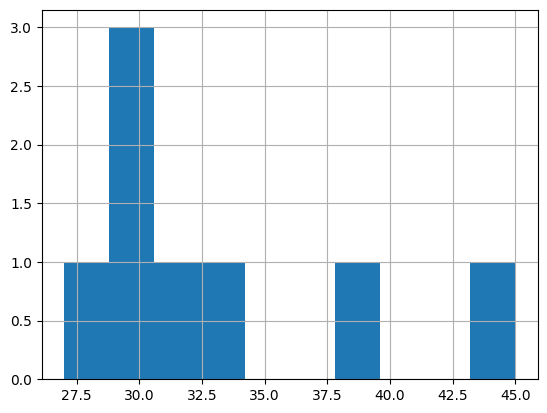

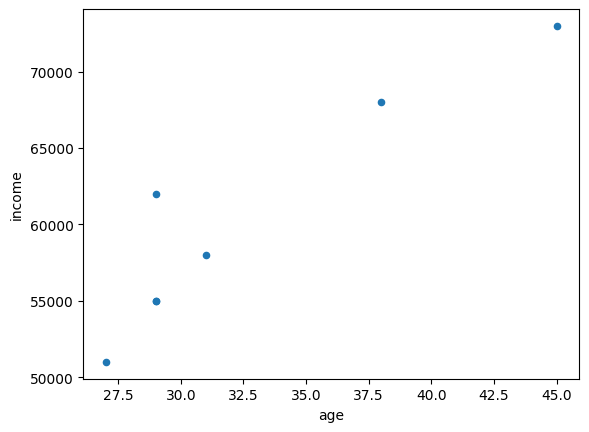

In [ ]:
# Basic Visualization
df2["age"].hist()
df2.plot(kind='scatter', x='age', y='income')